Introduction

Proper feeding and prompt treatment are critical factors that influence both recovery and mortality outcomes in childhood diarrhea. In Kenya, caregiver practices during diarrhea episodes play a central role in determining whether children receive adequate nutrition and effective treatment. 

This notebook assesses caregiver feeding practices and treatment preferences, with the goal of determining whether these behaviors align with the standards recommended by the World Health Organization (WHO). By examining food intake decisions and treatment choices such as zinc supplementation, antibiotic use, and health facility visits, the analysis provides insights into gaps, strengths, and opportunities for improving diarrhea management at the household level.

Objectives

The purpose of this notebook is to assess caregiver practices in managing childhood diarrhea, focusing on feeding and treatment behaviors. Specifically, the objectives are:

1. **Evaluate feeding practices – food**  
   - Examine caregiver decisions on food intake during diarrhea episodes (increased, same, or decreased).  
   - Determine whether nutritional support is maintained or compromised.  
   - Relate findings to child health outcomes and household food security.

2. **Investigate treatment practices**  
   - Analyze the use of zinc supplementation, antibiotics, and health facility visits.  
   - Assess alignment with WHO recommendations for diarrhea management.  
   - Identify gaps in treatment adoption and access to care.

3. **Synthesize findings**  
   - Compare food and treatment practices to distinguish recommended versus non-recommended behaviors.  
   - Provide insights for strengthening caregiver education, WASH programs, and treatment supply chains.

Dataset Overview

This analysis uses Demographic and Health Survey (DHS) data, the same source applied in Notebook 1. For this notebook, the focus shifts from prevalence and ORS usage to caregiver feeding and treatment practices during childhood diarrhea episodes. 

Key columns retained include:
- **SurveyYear** → Year the DHS survey was conducted.  
- **Indicator** → Feeding and treatment practices measured (e.g., "Feeding practices: Increased food," "Treatment: Zinc," "Treatment: Health facility visit").  
- **Value** → Percentage of children associated with each practice.  
- **DenominatorWeighted** → Weighted sample size accounting for survey design.  
- **DenominatorUnweighted** → Raw number of respondents.  
- **CharacteristicLabel** → Subgroup category (e.g., "Total," "Urban," "Rural").  
- **ByVariableLabel** → Additional context for the indicator (e.g., "Three years preceding survey").  

These columns provide the foundation for analyzing caregiver behaviors, comparing practices against WHO recommendations, and identifying gaps in feeding and treatment adoption.

 Loading Data 

In [177]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [178]:
# Loaing the Data set
pd.read_csv('diarrhea_national_ken.csv')
# dataset Overview
df = pd.read_csv('diarrhea_national_ken.csv')
df = df[df['IsPreferred'] == 1]
df.head()
df.info()
df.describe()
print()

<class 'pandas.core.frame.DataFrame'>
Index: 206 entries, 1 to 444
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ISO3                    206 non-null    object 
 1   DataId                  206 non-null    int64  
 2   Indicator               206 non-null    object 
 3   Value                   206 non-null    float64
 4   Precision               206 non-null    int64  
 5   DHS_CountryCode         206 non-null    object 
 6   CountryName             206 non-null    object 
 7   SurveyYear              206 non-null    int64  
 8   SurveyId                206 non-null    object 
 9   IndicatorId             206 non-null    object 
 10  IndicatorOrder          206 non-null    int64  
 11  IndicatorType           206 non-null    object 
 12  CharacteristicId        206 non-null    int64  
 13  CharacteristicOrder     206 non-null    int64  
 14  CharacteristicCategory  206 non-null    object 

In [179]:
#Removing Unnecessary Columns
columns_to_keep = [
    "SurveyYear",
    "Indicator",
    "Value",
    "DenominatorWeighted",
    "DenominatorUnweighted",
    "CharacteristicLabel",
    "ByVariableLabel"
]
df = df[columns_to_keep]
df.head()

,SurveyYear,Indicator,Value,DenominatorWeighted,DenominatorUnweighted,CharacteristicLabel,ByVariableLabel
1,1989,Children with diarrhea,12.7,6589.0,6407.0,Total,Five years preceding the survey
3,1989,Number of children born in the last five (or t...,6589.0,NaN,6407.0,Total,Five years preceding the survey
5,1989,Number of children born in the last five (or t...,6407.0,6589.0,NaN,Total,Five years preceding the survey
7,1989,Feeding practices during diarrhea: Increased a...,28.7,838.0,833.0,Total,Five years preceding the survey
9,1989,Feeding practices during diarrhea: Same amount...,71.3,838.0,833.0,Total,Five years preceding the survey


Objective 1: Evaluate feeding practices- Food

In [180]:
#Filtering dataset for feeding practices related to Food.
feeding_practices = df[df['Indicator'].str.contains('food')].copy()
feeding_practices.head()



,SurveyYear,Indicator,Value,DenominatorWeighted,DenominatorUnweighted,CharacteristicLabel,ByVariableLabel
13,1989,Feeding practices during diarrhea: Increased a...,5.8,838.0,833.0,Total,Five years preceding the survey
15,1989,Feeding practices during diarrhea: Same amount...,94.2,838.0,833.0,Total,Five years preceding the survey
161,2003,Feeding practices during diarrhea: Increased a...,6.6,888.0,866.0,Total,Five years preceding the survey
163,2003,Feeding practices during diarrhea: Same amount...,34.5,888.0,866.0,Total,Five years preceding the survey
165,2003,Feeding practices during diarrhea: Somewhat le...,25.8,888.0,866.0,Total,Five years preceding the survey


In [181]:
#Checking unique values in the 'Indicator' column
unique_indicators = feeding_practices['Indicator'].unique()
print(unique_indicators)
# shortening the indicator names for better visualization
# Create a mapping for shorter labels
label_map = {
    "Feeding practices during diarrhea: Decreased amount of food": "Decreased food",
    "Feeding practices during diarrhea: Increased amount of food": "Increased food",
    "Feeding practices during diarrhea: Much less food": "Much less",
    "Feeding practices during diarrhea: Never gave food": "Never gave",
    "Feeding practices during diarrhea: Same amount of food": "Same",
    "Feeding practices during diarrhea: Somewhat less food": "Somewhat less",
    "Feeding practices during diarrhea: Stopped food completely": "Stopped",
    "Feeding practices during diarrhea: don't know or missing on food given": "Unknown"
}

feeding_practices["IndicatorShort"] = feeding_practices["Indicator"].map(label_map)

['Feeding practices during diarrhea: Increased amount of food'
 'Feeding practices during diarrhea: Same amount of food'
 'Feeding practices during diarrhea: Somewhat less food'
 'Feeding practices during diarrhea: Much less food'
 'Feeding practices during diarrhea: Stopped food completely'
 'Feeding practices during diarrhea: Never gave food'
 "Feeding practices during diarrhea: don't know or missing on food given"]


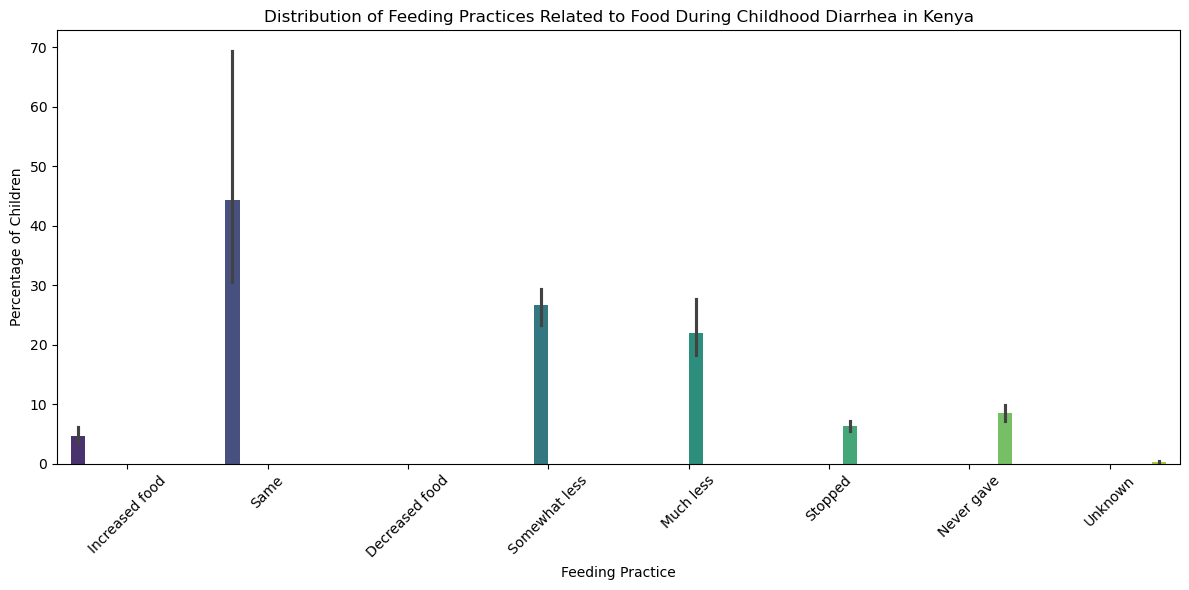

In [182]:
#Apply ordering BEFORE plotting
order = ["Increased food", "Same", "Decreased food", "Somewhat less", "Much less", "Stopped", "Never gave", "Unknown"]
feeding_practices["IndicatorShort"] = pd.Categorical(feeding_practices["IndicatorShort"], categories=order, ordered=True)

# Now plot
plt.figure(figsize=(12, 6))
sns.barplot(x="IndicatorShort", y="Value", hue="IndicatorShort", data=feeding_practices, palette="viridis", legend=False)
plt.title("Distribution of Feeding Practices Related to Food During Childhood Diarrhea in Kenya")
plt.xlabel("Feeding Practice")
plt.ylabel("Percentage of Children")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("feeding_practices.png", dpi=300, bbox_inches='tight')
plt.show()

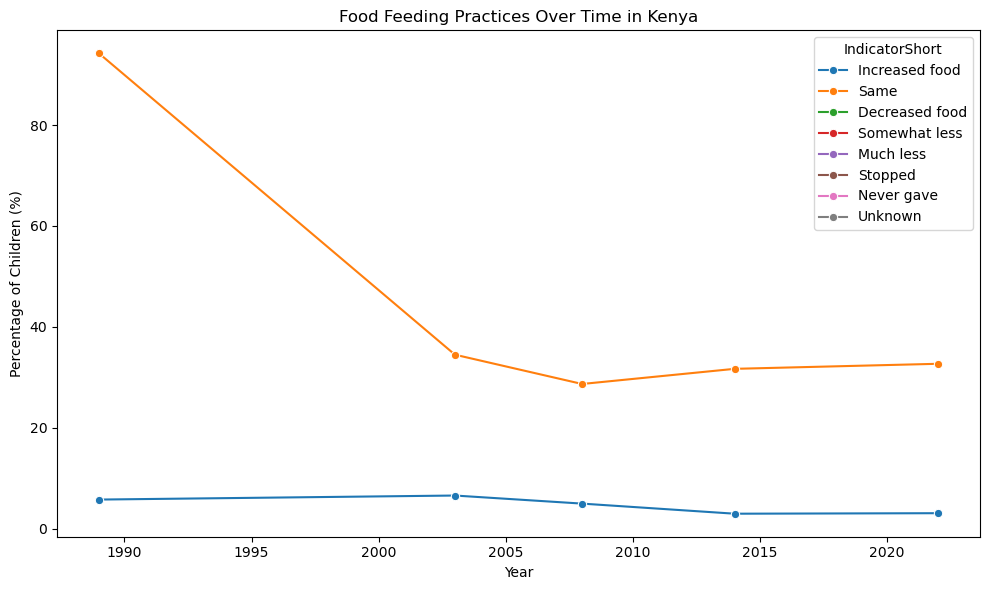

In [183]:
# trend over time for key food practices
food_trend = feeding_practices[feeding_practices['IndicatorShort'].isin(["Increased food", "Same"])].copy()

plt.figure(figsize=(10,6))
sns.lineplot(x='SurveyYear', y='Value', hue='IndicatorShort', data=food_trend, marker='o')
plt.title('Food Feeding Practices Over Time in Kenya')
plt.xlabel('Year')
plt.ylabel('Percentage of Children (%)')
plt.tight_layout()
plt.savefig('food_practices_trend.png', dpi=150)
plt.show()

### Trend in Food Feeding Practices Over Time (1989–2022)

The line chart reveals a striking shift in caregiver feeding behavior during childhood diarrhea episodes in Kenya over three decades.
In 1989, the vast majority of caregivers (over 90%) maintained the same amount of food during diarrhea episodes. However, this practice declined sharply over time, dropping to around 33% by 2022. This shift suggests that caregivers are moving away from a single dominant practice toward a more varied range of feeding behaviors — some beneficial, others potentially harmful.
The proportion of caregivers increasing food intake remained consistently low throughout all survey years, never exceeding 6%. This indicates that the WHO recommended practice of increasing food during diarrhea to support recovery has not been widely adopted in Kenya despite decades of public health campaigns.
These trends highlight a critical gap: as the "same food" practice declines, it is not being replaced by the recommended "increased food" behavior. Strengthening caregiver education on nutritional support during illness 
remains an urgent priority.

### Interpretation of Feeding Practices

The chart shows the distribution of caregiver feeding practices during childhood diarrhea episodes in Kenya. The most common behaviors observed are **keeping the same amount of food** and **decreasing food intake**, while fewer caregivers report **increasing food** as recommended by WHO. 

Risky practices such as **stopping food completely**, **never giving food**, or **reducing food significantly** are still present, though less frequent. These findings highlight that many caregivers do not fully follow WHO guidance, which emphasizes continued feeding during diarrhea to support recovery and reduce mortality. ### Comparative Note

In Notebook 1, the analysis of fluid intake showed that many caregivers reduced or withheld fluids during childhood diarrhea, despite WHO recommendations to increase fluid intake. A similar pattern emerges here with food practices: while some caregivers maintain or increase feeding, a significant proportion reduce food or stop it altogether. 

This consistency across both fluids and food highlights a broader challenge in caregiver practices — the tendency to limit intake during illness. Such behaviors increase the risk of poor recovery and higher mortality. Strengthening caregiver education and reinforcing WHO guidance on both fluids and feeding are therefore critical for improving childhood diarrhea management in Kenya.

Objective 2: Investigating treatment practices

Filtering Treatment Indicators and Renaming Labels

To analyze treatment practices during childhood diarrhea, the dataset was first filtered to include only indicators related to treatment. This step ensures that the analysis focuses specifically on medical and care-seeking behaviors rather than feeding or fluid practices.

After filtering, the indicators were inspected using the `.unique()` function to identify all treatment-related categories present in the dataset. These included practices such as **ORS**, **Zinc supplements**, **Antibiotics**, **Intravenous solution**, **Home remedies**, and whether **advice or treatment was sought**.

Since the original indicator names were long and difficult to display on charts, a **mapping dictionary** was created to shorten them into cleaner, more readable labels. For example:
- `"Treatment of diarrhea: Oral rehydration solution (ORS)"` → `"ORS"`
- `"Treatment of diarrhea: Zinc supplements"` → `"Zinc"`
- `"Treatment of diarrhea: Advice or treatment was sought"` → `"Advice/Treatment sought"`

This renaming step improves visualization clarity and makes the results easier to interpret. The shortened labels were stored in a new column called `IndicatorShort`, which was then used for plotting the distribution of treatment practices.

In [184]:
df.head()
#Filtering dataset for treatment practices
treatment_practices = df[df['Indicator'].str.contains('Treatment')].copy()
treatment_practices.head()
#unique values in the 'Indicator' column for treatment practices
unique_treatment_indicators = treatment_practices['Indicator'].unique()
print(unique_treatment_indicators)


['Treatment of diarrhea: Advice or treatment was sought'
 'Treatment of diarrhea: Oral rehydration solution (ORS)'
 'Treatment of diarrhea: Either ORS or RHF'
 'Treatment of diarrhea: Increased fluids'
 'Treatment of diarrhea: ORT or increased fluids'
 'Treatment of diarrhea: No ORS, RHF or increased fluids'
 'Treatment of diarrhea: Antibiotics'
 'Treatment of diarrhea: Intravenous solution'
 'Treatment of diarrhea: Home remedy - other'
 'Treatment of diarrhea: No treatment'
 "Treatment of diarrhea: don't know or missing"
 'Treatment of diarrhea: Recommended home fluids (RHF) at home'
 'Treatment of diarrhea: Zinc supplements'
 'Treatment of diarrhea: Antimotility drugs'
 'Treatment of diarrhea: Injection']


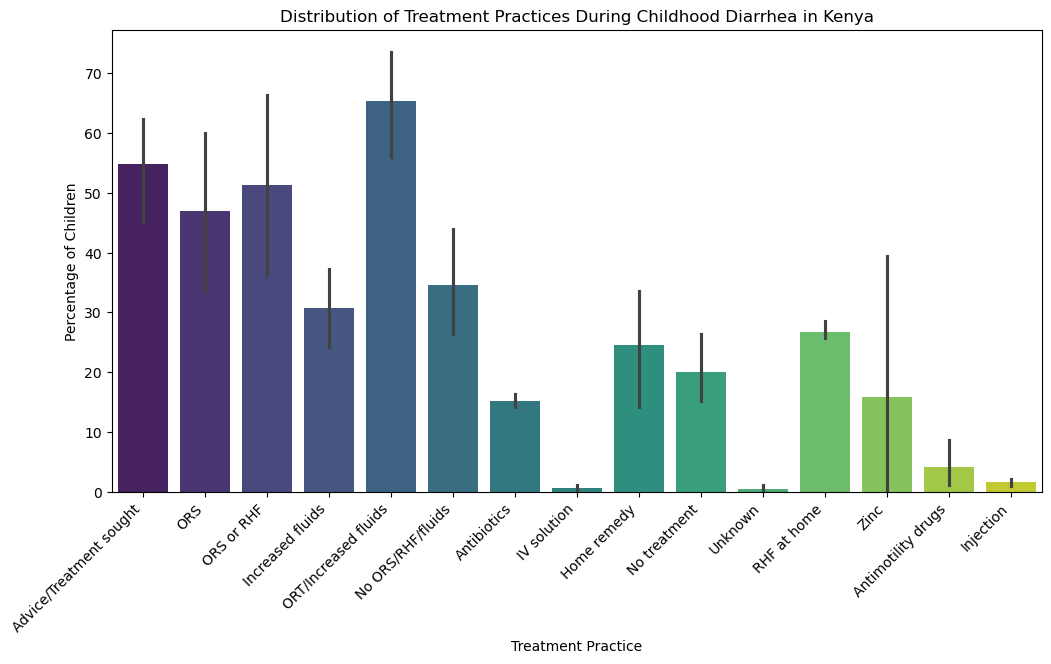

In [185]:
#renaming the indicator names for better visualization
treatment_label_map = {
    "Treatment of diarrhea: Advice or treatment was sought": "Advice/Treatment sought",
    "Treatment of diarrhea: Oral rehydration solution (ORS)": "ORS",
    "Treatment of diarrhea: Either ORS or RHF": "ORS or RHF",
    "Treatment of diarrhea: Increased fluids": "Increased fluids",
    "Treatment of diarrhea: ORT or increased fluids": "ORT/Increased fluids",
    "Treatment of diarrhea: No ORS, RHF or increased fluids": "No ORS/RHF/fluids",
    "Treatment of diarrhea: Antibiotics": "Antibiotics",
    "Treatment of diarrhea: Intravenous solution": "IV solution",
    "Treatment of diarrhea: Home remedy - other": "Home remedy",
    "Treatment of diarrhea: No treatment": "No treatment",
    "Treatment of diarrhea: don't know or missing": "Unknown",
    "Treatment of diarrhea: Recommended home fluids (RHF) at home": "RHF at home",
    "Treatment of diarrhea: Zinc supplements": "Zinc",
    "Treatment of diarrhea: Antimotility drugs": "Antimotility drugs",
    "Treatment of diarrhea: Injection": "Injection"
}

#Applying the mapping to create a new column with shorter labels
treatment_practices["IndicatorShort"] = treatment_practices["Indicator"].map(treatment_label_map)

# summarizing and plotting
treatment_summary = treatment_practices.groupby("IndicatorShort")["Value"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x="IndicatorShort", y="Value", hue="IndicatorShort", data=treatment_practices, palette="viridis", legend=False)
plt.title("Distribution of Treatment Practices During Childhood Diarrhea in Kenya")
plt.xlabel("Treatment Practice")
plt.ylabel("Percentage of Children")
plt.xticks(rotation=45, ha="right")
plt.savefig("treatment_practices.png", dpi=300, bbox_inches='tight')
plt.show()

Interpretation of Treatment Practices

The chart illustrates the distribution of different treatment practices used during childhood diarrhea episodes in Kenya. The most common approaches include **Recommended Home Fluids (RHF) at home**, **ORS or RHF**, and **ORT/Increased fluids**, all of which align with WHO recommendations for managing diarrhea. These practices emphasize continued hydration and are considered effective in reducing mortality.
A significant proportion of caregivers also reported **seeking advice or treatment**, which reflects positive care-seeking behavior. However, less recommended practices such as **antibiotics**, **antimotility drugs**, and **injections** appear in the data, despite WHO guidance discouraging their routine use for diarrhea management. Risky categories like **No treatment** and **No ORS/RHF/fluids** highlight gaps in caregiver knowledge and access to appropriate interventions.
Overall, the findings suggest that while many caregivers adopt recommended practices, there is still notable reliance on inappropriate treatments and instances of no intervention. This underscores the need for stronger public health education and improved access to essential supplies like ORS and zinc.

Objective 3: Synthesis of Feeding and Treatment Practices



This objective integrates findings from both feeding and treatment practices to provide a holistic view of caregiver responses to childhood diarrhea. By comparing these two domains, we can distinguish between recommended behaviors (such as continued feeding, increased fluids, ORS, and zinc supplementation) and non-recommended practices (such as reducing food, stopping fluids, reliance on antibiotics, injections, or no treatment). 

The synthesis highlights areas where caregivers follow WHO guidance and areas where harmful practices persist. These insights are critical for strengthening caregiver education, improving WASH (Water, Sanitation, and Hygiene) programs, and ensuring reliable supply chains for essential treatments like ORS and zinc.

In [186]:
#Defining recommended vs non-recommended categories.
recommended = [
    "Feeding practices during diarrhea: Increased amount of fluids",
    "Feeding practices during diarrhea: Increased amount of food",
    "Feeding practices during diarrhea: Continued feeding, and ORT and/or increased fluids",
    "Feeding practices during diarrhea: ORT and continued feeding",
    "Treatment of diarrhea: Oral rehydration solution (ORS)",
    "Treatment of diarrhea: Either ORS or RHF",
    "Treatment of diarrhea: Increased fluids",
    "Treatment of diarrhea: ORT or increased fluids",
    "Treatment of diarrhea: Recommended home fluids (RHF) at home",
    "Treatment of diarrhea: Zinc supplements"
]

non_recommended = [
    "Feeding practices during diarrhea: Decreased amount of fluids",
    "Feeding practices during diarrhea: Somewhat less fluids",
    "Feeding practices during diarrhea: Much less fluids",
    "Feeding practices during diarrhea: Stopped fluids completely",
    "Feeding practices during diarrhea: Decreased amount of food",
    "Feeding practices during diarrhea: Somewhat less food",
    "Feeding practices during diarrhea: Much less food",
    "Feeding practices during diarrhea: Stopped food completely",
    "Feeding practices during diarrhea: Never gave food",
    "Treatment of diarrhea: Antibiotics",
    "Treatment of diarrhea: Antimotility drugs",
    "Treatment of diarrhea: Injection",
    "Treatment of diarrhea: No treatment",
    "Treatment of diarrhea: No ORS, RHF or increased fluids"
]

def classify_practice(indicator):
    if indicator in recommended:
        return "Recommended"
    elif indicator in non_recommended:
        return "Non-Recommended"
    else:
        return "Other"

df["PracticeGroup"] = df["Indicator"].apply(classify_practice)
focus_indicators = df[df["Indicator"].str.contains("Feeding practices|Treatment of diarrhea")]

#aggregate statistics
summary = focus_indicators.groupby("PracticeGroup")["Value"].mean().reset_index()
summary



,PracticeGroup,Value
0,Non-Recommended,15.724490
1,Other,37.096429
2,Recommended,36.223913


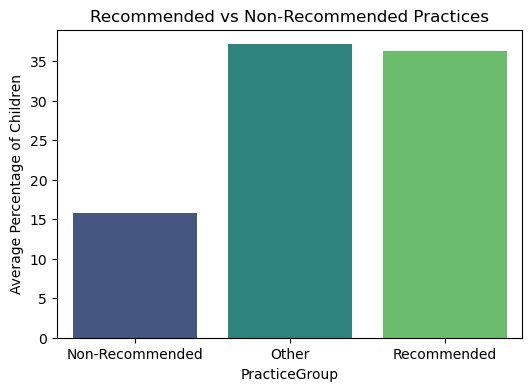

In [187]:
#Visualization of recommended vs non-recommended practices
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="PracticeGroup", y="Value", hue="PracticeGroup", data=summary, palette="viridis", legend=False)
plt.title("Recommended vs Non-Recommended Practices")
plt.ylabel("Average Percentage of Children")
plt.savefig("recommended_vs_non_recommended.png", dpi=300, bbox_inches='tight')
plt.show()

### Interpretation of Recommended vs Non-Recommended Practices

The graph compares caregiver behaviors during childhood diarrhea episodes. It shows that **recommended practices** (such as ORS, zinc, increased fluids, and continued feeding) are adopted more often than **non-recommended practices** (like antibiotics, injections, or stopping food/fluids). 

The **“Other” group** represents indicators not directly classified as recommended or non-recommended, and its relatively high value reflects the presence of supportive or neutral practices (e.g., advice sought, knowledge of ORS). 

Overall, the synthesis highlights that while positive behaviors are common, harmful practices still persist. This underscores the need for stronger caregiver education, reliable supply chains for ORS and zinc, and reinforcement of WASH programs to reduce reliance on non-recommended treatments.

## Final Summary and Recommendations

### Key Findings
- **Objective 1 (Feeding Practices):** Many caregivers continued feeding and sometimes increased food during diarrhea episodes, which aligns with WHO recommendations. However, a significant proportion reduced or stopped food, reflecting harmful practices that can worsen child outcomes.
- **Objective 2 (Treatment Practices):** Recommended treatments such as ORS, zinc, and RHF were adopted, but antibiotics, injections, and “no treatment” were still common. This shows both progress and persistent gaps in caregiver knowledge and access.
- **Objective 3 (Synthesis):** Statistical comparison revealed that recommended practices are more prevalent than non-recommended ones, but harmful behaviors remain significant. The “Other” category highlights neutral or supportive practices (e.g., advice sought, knowledge of ORS) that don’t directly fit into WHO’s recommended/non-recommended framework.

### Overall Insights
- Caregivers demonstrate partial adherence to WHO guidelines, with positive behaviors like ORS use, zinc supplementation, and continued feeding being widespread.
- Harmful practices such as stopping food/fluids or relying on antibiotics/injections persist, indicating gaps in education and supply chains.
- Neutral indicators (like advice sought or knowledge of ORS) suggest opportunities for strengthening caregiver awareness and health system support.

### Recommendations
1. **Strengthen Caregiver Education:** Expand community health programs to emphasize the importance of continued feeding, increased fluids, and ORS/zinc use during diarrhea episodes.
2. **Improve Supply Chains:** Ensure consistent availability of ORS and zinc supplements at local health facilities and through community health workers.
3. **Reinforce WASH Programs:** Reduce diarrhea incidence through improved water, sanitation, and hygiene interventions.
4. **Target Harmful Practices:** Address misconceptions around antibiotics, injections, and stopping food/fluids through tailored behavior change communication.
5. **Leverage Neutral Practices:** Build on existing caregiver behaviors such as seeking advice and knowledge of ORS to strengthen adherence to recommended practices.

### Conclusion
The analysis across feeding and treatment practices shows encouraging trends but also highlights persistent harmful behaviors. By combining education, reliable supply chains, and WASH interventions, Kenya can significantly reduce childhood diarrhea morbidity and mortality. This synthesis provides actionable insights for policymakers, NGOs, and health practitioners working to improve child health outcomes.